<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/drafts/Notebook4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%config InlineBackend.figure_formats = ["retina"]

# Data and the State (DATA 20195/30195)

# Lab 4: Migration and relocation

After running the first cell to install packages, you must restart the runtime so that maup and the interactive maps work properly. To do so, click on the dropdown next to "Run all" in the menu bar and then select "Restart session."

In [2]:
!pip install -q geopandas networkx us census xlrd
!pip install -q "git+https://github.com/ds-20195/notebooks#egg=ds20195&subdirectory=lib"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.9 MB/s eta 0:00:00


In [3]:
import json

import geopandas as gpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests
import us

from census import Census
from shapely.geometry import Point

from ds20195 import google_sheets_credentials, generate_flow_sheet


state_fips  = "17"    # Illinois
county_fips = "031"   # Cook County
state_name  = "Illinois"
county_name = "Cook County"

census = Census("", year=2020)

In [4]:
# @markdown This code cell checks that the census API is working
try:
    county_populations = census.pl.get(
        ("NAME"),
        geo={"for": "state:17"}
    )
    print("The Census API appears to be working!")
except Exception:
    raise RuntimeError(
        "Error fetching data from the Census API. "
        "Please try disconnecting and reconnecting the runtime. "
        "If the problem persists after 2 resets, you will need to use our backup data cells to "
        "complete the lab"
    )


KeyboardInterrupt: 

## ACS migration flows

In addition to standard demographic data, the ACS also collects information on residential mobility; in particular the survey asks respondents where they lived one year prior to the survey. We will use this data to construct county-to-county migration flow diagrams.

Data sourced from the "Net Gross US" document at [https://www.census.gov/data/tables/2020/demo/geographic-mobility/county-to-county-migration-2016-2020.html](https://www.census.gov/data/tables/2020/demo/geographic-mobility/county-to-county-migration-2016-2020.html)

In [5]:
# @markdown This cell makes a request against the Census api and then stores
# @markdown the output data in a list called `raw_flows`

# The census package is not useful here, so we will just make construct the request ourselves
try:
  import warnings
  warnings.filterwarnings("ignore") # gets rid of the "unverified request" warning
  response = requests.get(
    "https://www2.census.gov/programs-surveys/demo/tables/geographic-mobility/2020/county-to-county-migration-2016-2020/county-to-county-migration-flows/Net_Gross_US.txt",
    verify=False,
  )

  # Check that the response succeeded
  if response.status_code != 200:
    raise RuntimeError(
        "Could not retrieve data from the Census API. "
    )

  # Deal with the text encoding.
  decoded_response = response.content.decode("latin1")

  # Split the text on a new line character and store in list
  raw_flows = decoded_response.split("\n")

except Exception:
  raise Exception("BACKUP DATA NOT AVAILABLE YET")

Let's take a look at the first few items in the `raw_flows` list.

In [6]:
for i in range(3):
  print(raw_flows[i])

001001001003 Alabama                       Autauga County                      Alabama                       Baldwin County                            30       37      489      395     -459      396      519      398 
001001001005 Alabama                       Autauga County                      Alabama                       Barbour County                             5        8        0       23        5        8        5        8 
001001001007 Alabama                       Autauga County                      Alabama                       Bibb County                               12       18       48       61      -36       62       60       65 


Notice that each row has a large amount of white space between the entries and that the beginning of the entries align with each other. This is called _fixed width column formatting_ and it is a common data distribution format for the Census.


In the case of migration flows, the Census also publishes [additional documentation](https://www.census.gov/topics/population/migration/guidance/county-to-county-migration-flows/2016-2020.html) that clarifies what position ranges represent. We are interested in the table on page 11 under the header **County/MCD-to-County/MCD Net and Gross Migration Files**.



| Field Description | Field Position |
|---|---|
| State/U.S. Island Area/Foreign Region Code of Geography A (FIPS) | 1–3 |
| FIPS County Code of Geography A | 4–6 |
| State/U.S. Island Area/Foreign Region Code of Geography B (FIPS) | 7–9 |
| FIPS County Code of Geography B | 10–12 |
| State/U.S. Island Area/Foreign Region Name of Geography A | 14–43 |
| County Name of Geography A | 44–78 |
| State/U.S. Island Area/Foreign Region Name of Geography B | 80–109 |
| County Name of Geography B | 110–144 |
| Flow from Geography B to Geography A – Estimate | 146–153 |
| Flow from Geography B to Geography A – MOE | 155–162 |
| Counterflow from Geography A to Geography B – Estimate | 164–171 |
| Counterflow from Geography A to Geography B – MOE | 173–180 |
| Net Migration from Geography B to Geography A – Estimate | 182–189 |
| Net Migration from Geography B to Geography A – MOE | 191–198 |
| Gross Migration between Geography A and Geography B – Estimate | 200–207 |
| Gross Migration between Geography A and Geography B – MOE | 209–216 |


> Note: MOE is an abbreviation for "Margin Of Error"

Parsing this data will involve 3 steps. First, we create more convenient, sorted names for the columns.

In [7]:
place_columns = [
    "a_fips",
    "b_fips",
    "a_state",
    "a_county",
    "b_state",
    "b_county",
]

flow_columns = [
    "b_to_a_flow_est",
    "b_to_a_flow_moe",
    "a_to_b_flow_est",
    "a_to_b_moe",
    "net_flow_est",
    "net_flow_moe",
    "gross_flow_est",
    "gross_flow_moe",
]

columns = place_columns + flow_columns

Then we create a `get_migration_value` helper function that will handle the slicing to the correct column width, and a `fips_is_numeric` helper function to filter out non-US localities.

In [8]:
def get_migration_value(item_name, input_string):
    # The table the Census publishes is 1-indexed so we need to adjust slice
    # ranges carefully
    col_to_slice = {
        "a_fips": (1,6), # Start at 1 to strip the leading 0 in the state fips
        "b_fips": (7,12), # Start at 7 to strip the leading 0 in the state fips
        "a_state": (13,43),
        "a_county": (43,78),
        "b_state": (79,109),
        "b_county": (109,144),
        "b_to_a_flow_est": (145,153),
        "b_to_a_flow_moe": (154,162),
        "a_to_b_flow_est": (163,171),
        "a_to_b_moe": (172,180),
        "net_flow_est": (181,189),
        "net_flow_moe": (190,198),
        "gross_flow_est": (199,207),
        "gross_flow_moe": (208,216),
    }

    start_slice = col_to_slice[item_name][0]
    end_slice = col_to_slice[item_name][1]
    return input_string[start_slice:end_slice].strip() # .strip() removes the trailing whitespace

# This checks if each item in a fips code string like '01' is numeric.
# We need to check this since there is data about migration from other places
# (e.g. South America which has the fips "SAM") in the ACS data
def fips_is_numeric(fips_code):
    for char in fips_code:
        if not char.isdigit():
            return False
    return True

Now we iterate through each now, and construct a data dictionary containing the entries for each of the place and flow columns. These dictionaries are then consolidated into a Pandas DataFrame.

Since the migration flow is uniquely determined by the pair (starting county, ending county), we will also create a _MultiIndex_ on the dataframe that allows for dynamic filtering.

In [9]:
flow_df_data = []
for raw_flow_string in raw_flows[:-1]:
    data_dict = {}
    for col in columns:
        data_dict[col] = get_migration_value(col, raw_flow_string)

    if fips_is_numeric(data_dict["a_fips"]) and fips_is_numeric(data_dict["b_fips"]):
        flow_df_data.append(data_dict)

# Create a new multi-index using ('a_fips','b_fips') pairs
flow_df = pd.DataFrame(flow_df_data).set_index(["a_fips", "b_fips"])

for col in flow_columns:
    flow_df[col] = flow_df[col].astype(int)

In [10]:
flow_df

a_state         a_county      b_state  \
a_fips b_fips                                              
01001  01003       Alabama   Autauga County      Alabama   
       01005       Alabama   Autauga County      Alabama   
       01007       Alabama   Autauga County      Alabama   
       01015       Alabama   Autauga County      Alabama   
       01017       Alabama   Autauga County      Alabama   
...                    ...              ...          ...   
72153  72125   Puerto Rico  Yauco Municipio  Puerto Rico   
       72127   Puerto Rico  Yauco Municipio  Puerto Rico   
       72135   Puerto Rico  Yauco Municipio  Puerto Rico   
       72145   Puerto Rico  Yauco Municipio  Puerto Rico   
       72151   Puerto Rico  Yauco Municipio  Puerto Rico   

                           b_county  b_to_a_flow_est  b_to_a_flow_moe  \
a_fips b_fips                                                           
01001  01003         Baldwin County               30               37   
       01005         Barbour County                5                8   
       01007            Bibb County               12               18   
       01015         Calhoun County                2                4   
       01017        Chambers County                0               29   
...                             ...              ...              ...   
72153  72125   San Germán Municipio                0               30   
       72127     San Juan Municipio               26               43   
       72135     Toa Alta Municipio                0               30   
       72145    Vega Baja Municipio                3                8   
       72151      Yabucoa Municipio               74              114   

               a_to_b_flow_est  a_to_b_moe  net_flow_est  net_flow_moe  \
a_fips b_fips                                                            
01001  01003               489         395          -459           396   
       01005                 0          23             5             8   
       01007                48          61           -36            62   
       01015                23          32           -21            34   
       01017                 7          16            -7            16   
...                        ...         ...           ...           ...   
72153  72125                11          21           -11            21   
       72127                40          64           -14            76   
       72135                 1           3            -1             3   
       72145                 0          34             3             8   
       72151                 0          30            74           114   

               gross_flow_est  gross_flow_moe  
a_fips b_fips                                  
01001  01003              519             398  
       01005                5               8  
       01007               60              65  
       01015               25              31  
       01017                7              16  
...                       ...             ...  
72153  72125               11              21  
       72127               66              77  
       72135                1               3  
       72145                3               8  
       72151               74             114  

[406348 rows x 12 columns]

The output display of `flow_df` should now have two index columns on the left -- `a_fips` and `b_fips` -- the start point and end point. So the usual `.loc[<index>]` semantics still work, but '<index>' will take the form of an ordered pair.

In [11]:
flow_df.loc[('01001', '01003')]

,01001
,01003
a_state,Alabama
a_county,Autauga County
b_state,Alabama
b_county,Baldwin County
b_to_a_flow_est,30
b_to_a_flow_moe,37
a_to_b_flow_est,489
a_to_b_moe,395
net_flow_est,-459


### TASK: Migration to Cook County

Deterimine approximately how many people migrated to Cook County betwen 2016 and 2020.  

In [ ]:
# YOUR CODE HERE

# Don't forget to ask for help if you get stuck!

### Migration Between NYC Buroughs

With the ACS migration data, we can now answer some more interesting questions. For example, how do people move between the 5 boroughs of New York City?

In [12]:
nyc_county_fips_codes = {
    "The Bronx": "36005",      # Bronx County
    "Brooklyn": "36047",       # Kings County
    "Manhattan": "36061",      # New York County
    "Queens": "36081",         # Queens County
    "Staten Island": "36085",  # Richmond
}

In [13]:
county_to_county_fips_pairs = []
nyc_county_fips_list = list(nyc_county_fips_codes.values())
for fips1 in nyc_county_fips_list:
    for fips2 in nyc_county_fips_list:
        if fips1 != fips2:
            county_to_county_fips_pairs.append((fips1, fips2))

flow_df.loc[county_to_county_fips_pairs]

a_state         a_county   b_state         b_county  \
a_fips b_fips                                                         
36005  36047   New York     Bronx County  New York     Kings County   
       36061   New York     Bronx County  New York  New York County   
       36081   New York     Bronx County  New York    Queens County   
       36085   New York     Bronx County  New York  Richmond County   
36047  36005   New York     Kings County  New York     Bronx County   
       36061   New York     Kings County  New York  New York County   
       36081   New York     Kings County  New York    Queens County   
       36085   New York     Kings County  New York  Richmond County   
36061  36005   New York  New York County  New York     Bronx County   
       36047   New York  New York County  New York     Kings County   
       36081   New York  New York County  New York    Queens County   
       36085   New York  New York County  New York  Richmond County   
36081  36005   New York    Queens County  New York     Bronx County   
       36047   New York    Queens County  New York     Kings County   
       36061   New York    Queens County  New York  New York County   
       36085   New York    Queens County  New York  Richmond County   
36085  36005   New York  Richmond County  New York     Bronx County   
       36047   New York  Richmond County  New York     Kings County   
       36061   New York  Richmond County  New York  New York County   
       36081   New York  Richmond County  New York    Queens County   

               b_to_a_flow_est  b_to_a_flow_moe  a_to_b_flow_est  a_to_b_moe  \
a_fips b_fips                                                                  
36005  36047              6924              969             4040         716   
       36061             11469             1191             4965         883   
       36081              5242              978             3701         628   
       36085               461              183              267         166   
36047  36005              4040              716             6924         969   
       36061             21743             1419            12241        1085   
       36081              8942              889            14949        1381   
       36085              1038              254             6065        1014   
36061  36005              4965              883            11469        1191   
       36047             12241             1085            21743        1419   
       36081              5938              795             8427        1066   
       36085               427              141              560         248   
36081  36005              3701              628             5242         978   
       36047             14949             1381             8942         889   
       36061              8427             1066             5938         795   
       36085               791              240              859         277   
36085  36005               267              166              461         183   
       36047              6065             1014             1038         254   
       36061               560              248              427         141   
       36081               859              277              791         240   

               net_flow_est  net_flow_moe  gross_flow_est  gross_flow_moe  
a_fips b_fips                                                              
36005  36047           2884          1269           10964            1136  
       36061           6504          1490           16434            1475  
       36081           1541          1108            8943            1214  
       36085            194           260             728             234  
36047  36005          -2884          1269           10964            1136  
       36061           9502          1912           33984            1652  
       36081          -6007          1752           23891            1526  
       3

#### 30 Seconds on NetworkX

As discussed in lecture, we'll use the Python library called NetworkX as our main option to store graphs.

The following two code cells demonstrate the basic NetworkX workflow we will use:
1. Create an empty graph.
2. Add edges and nodes.
3. Display the graph with `nx.draw` or `nx.draw_networkx_edges`.

Re-run the following cells a few times and you'll see that the picture (the embedding) varies.

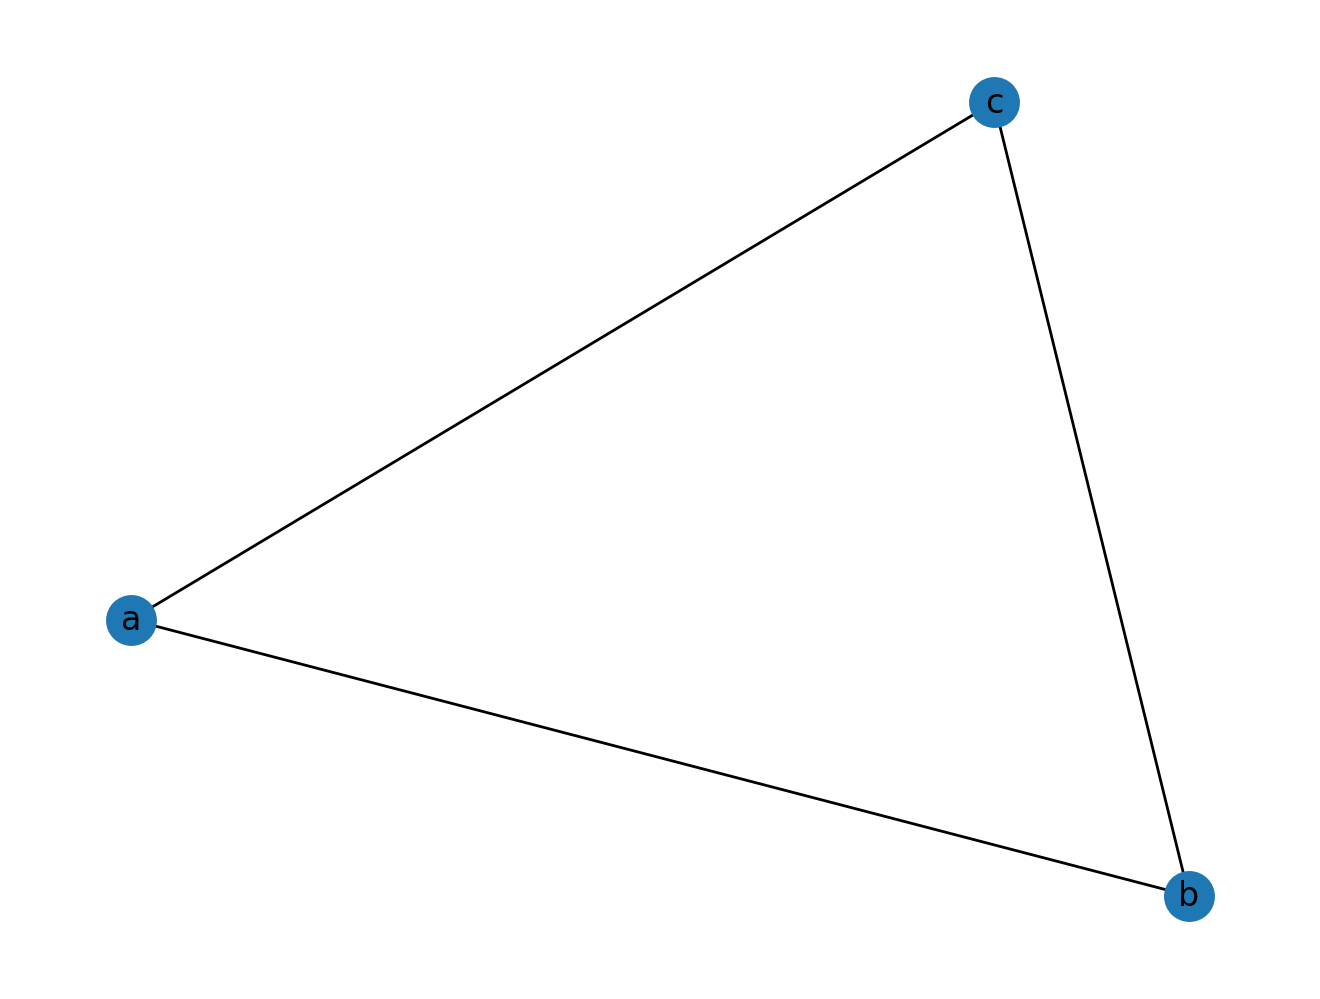

In [28]:
import networkx as nx # 'nx' is a common shortening of 'networkx'

graph1 = nx.Graph() # an undirected graph
graph1.add_edge("a", "b")
graph1.add_edge("a", "c")
graph1.add_edge("b", "c")

nx.draw(graph1, with_labels=True)

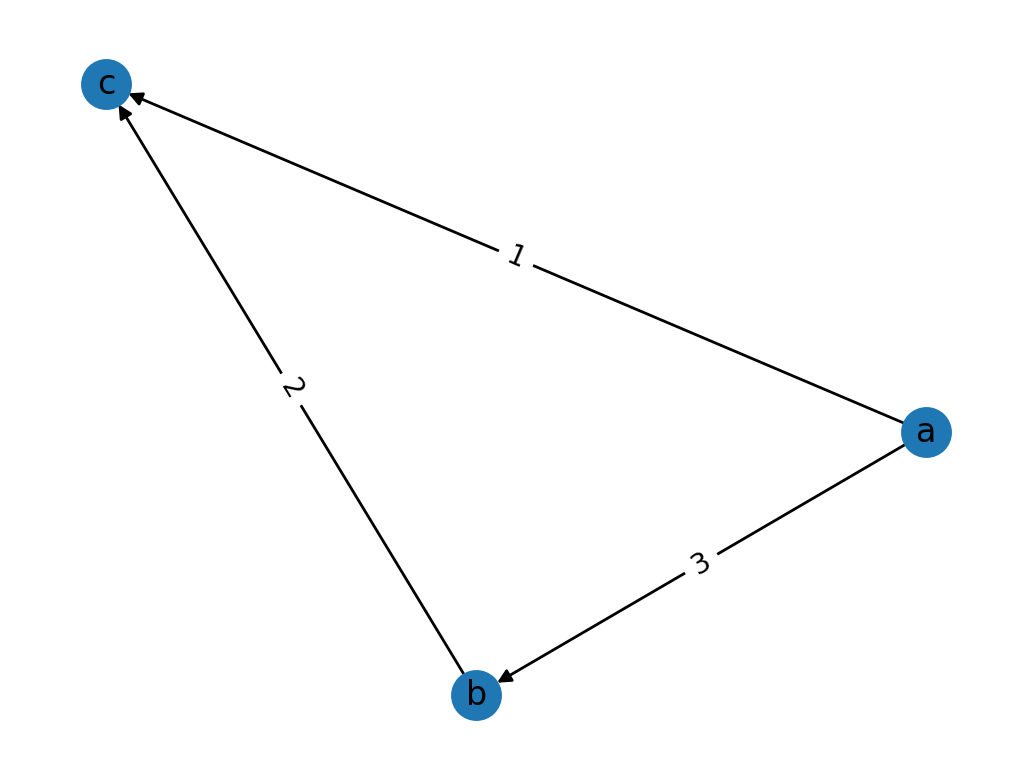

In [29]:
graph2 = nx.DiGraph()
graph2.add_edge("a", "b", weight=3)
graph2.add_edge("a", "c", weight=1)
graph2.add_edge("b", "c", weight=2)

fig, ax = plt.subplots()
pos = nx.spring_layout(graph2)
nx.draw(graph2, pos, ax=ax, with_labels=True)
nx.draw_networkx_edge_labels(graph2, pos, edge_labels=nx.get_edge_attributes(graph2, "weight"), ax=ax)
plt.show()

In [30]:
nx.node_link_data(graph2)

{'directed': True,
 'multigraph': False,
 'graph': {},
 'nodes': [{'id': 'a'}, {'id': 'b'}, {'id': 'c'}],
 'edges': [{'weight': 3, 'source': 'a', 'target': 'b'},
  {'weight': 1, 'source': 'a', 'target': 'c'},
  {'weight': 2, 'source': 'b', 'target': 'c'}]}

Back to NYC boroughs. We will now construct a GeoDataFrame of the 5 boroughs, and then plot the county-to-county flows on top of the plot of the GeoDataFrame using NetworkX.

First, let's construct a net migration graph.

> Syntax Note: `for key, value in dictionary.items()` is a convenient way to iterate over (key,value) pairs in Python.

In [31]:
net_migration_graph = nx.DiGraph()

for a_county, a_county_fips in nyc_county_fips_codes.items():
    for b_county, b_county_fips in nyc_county_fips_codes.items():
        if a_county == b_county:
            continue

        flow = flow_df.loc[(a_county_fips, b_county_fips)]
        net_flow = flow["net_flow_est"]
        if net_flow >= 0:
            net_migration_graph.add_edge(
                a_county,
                b_county,
                weight=net_flow, # weight is another attribute that can be used to decorate edges in graphs
            )
        else:
            net_migration_graph.add_edge(
                b_county,
                a_county,
                weight=-net_flow,
            )

In [32]:
# @markdown This cell retrieves the official US-wide county geodataframe and
# @markdown filters it to the NYC boroughs which is then stored in `nyc_county_gdf`

county_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip").set_index("GEOID").to_crs("EPSG:2163")
nyc_county_gdf = county_gdf.loc[nyc_county_fips_codes.values()]

# ADD BACKUP!!!

This next bit is a technical step. The `nx.draw` and `nx.draw_networkx_edges` functions accept a `pos` parameter which determines the position of each of the nodes of the graph. GeoPandas uses a library called Shapely under the hood to handle the drawing of its geometry objects, so to combine our NetworkX graph with the plot from the county GeoDataFrame, we need to convert the coordinates of the NetworkX nodes into to Shapely `point` objects.

We do this with a helper function aptly named `cast_point`.

In [33]:
def cast_point(p):
    return (p.xy[0][0], p.xy[1][0])

Now, plot it!  We suppress the axes (because those aren't helpful here) and choose some plotting details, then draw the shapes, points, and arrows for flows.

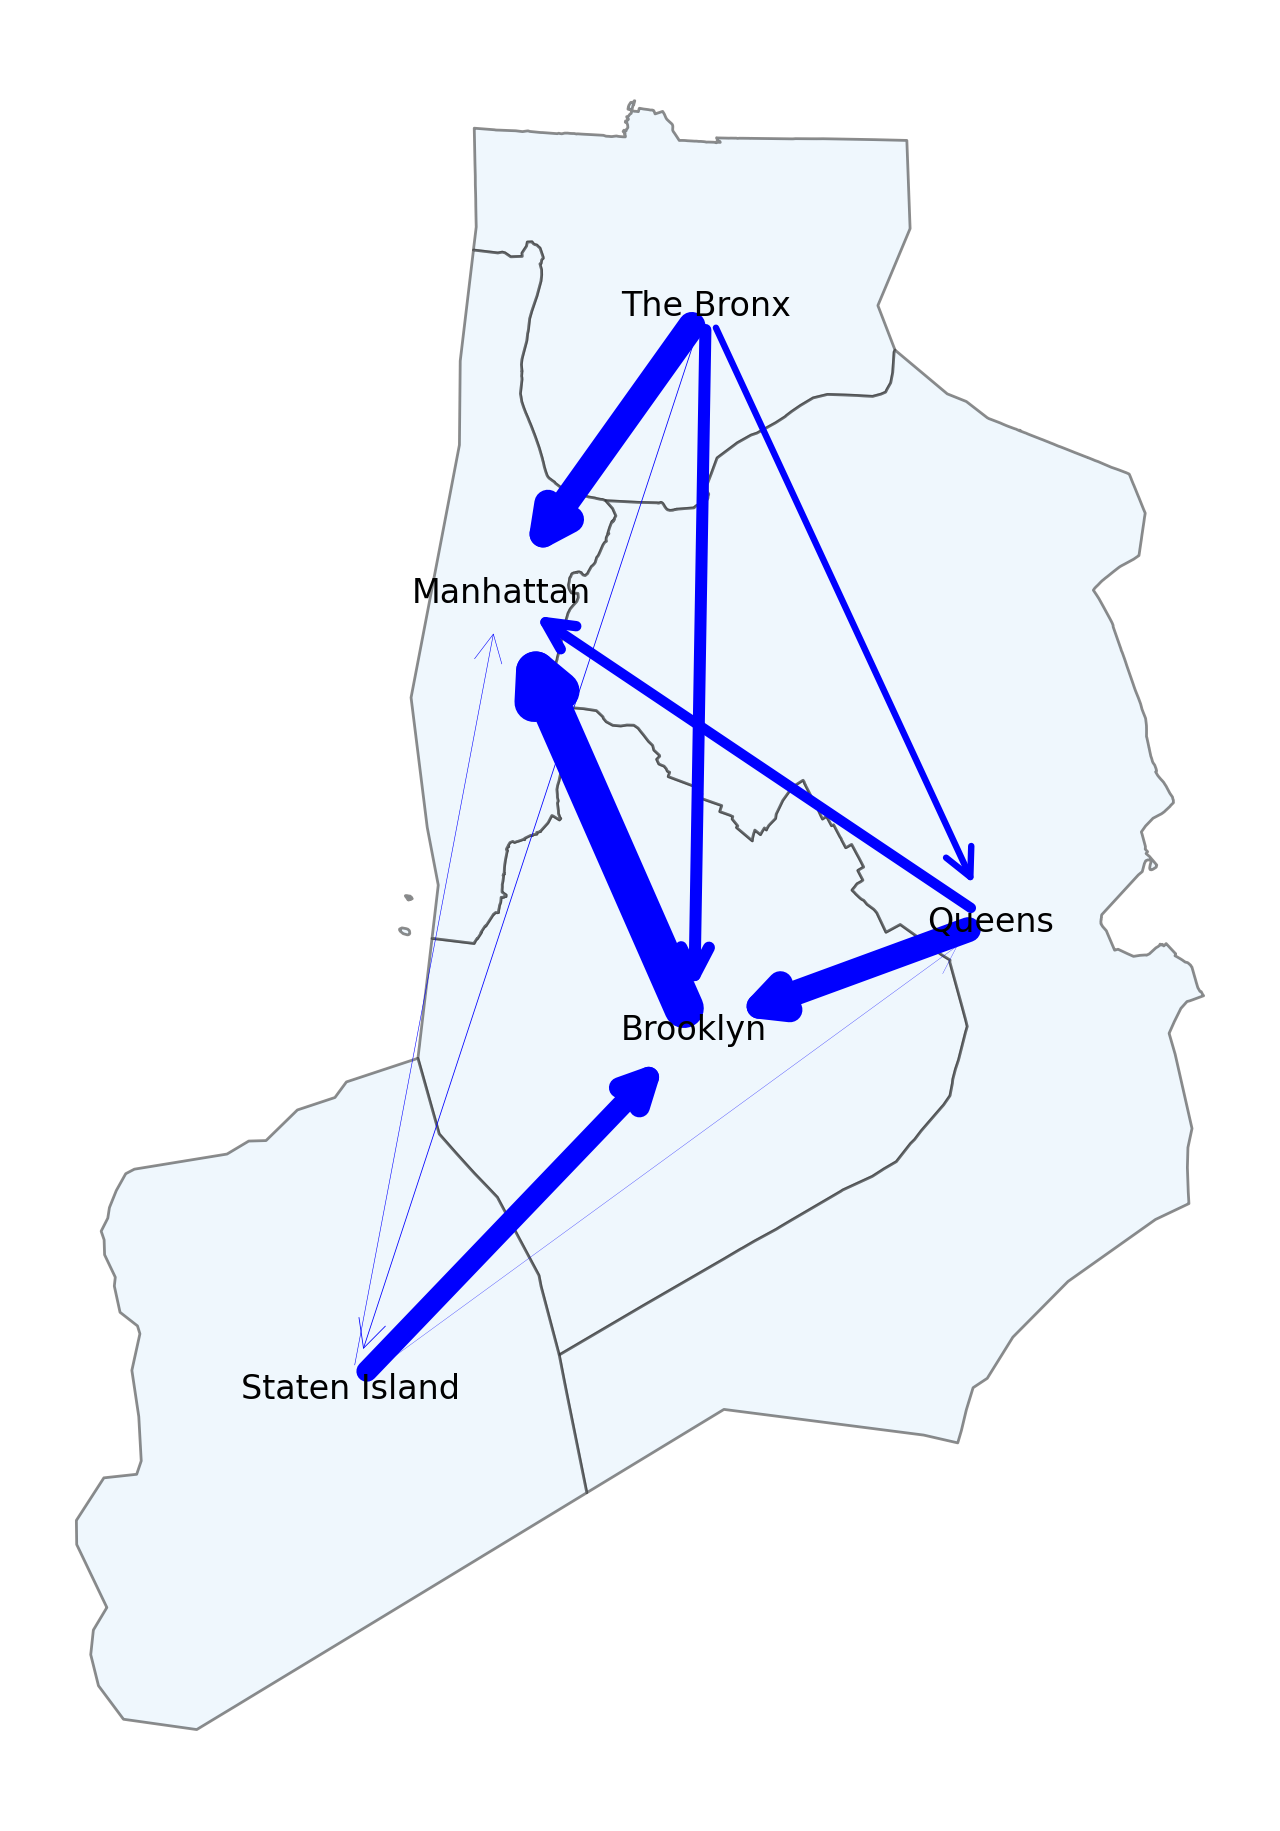

In [37]:
fig, ax = plt.subplots(figsize=(8, 16))
ax.axis("off")
nyc_county_gdf.plot(ax=ax, edgecolor="0.1", linewidth=1, color="#e1f1fd", alpha=0.5)

position_dict = {}
for borough, county_fips in nyc_county_fips_codes.items():
    position_dict[borough] = cast_point(nyc_county_gdf.loc[county_fips].geometry.representative_point())

nx.draw_networkx_labels(net_migration_graph, position_dict, ax=ax)

for edge in net_migration_graph.edges(data='weight'):
    nx.draw_networkx_edges(
        net_migration_graph,
        position_dict,
        edgelist=[edge],
        width=0.0015 * edge[2],
        ax=ax,
        edge_color="blue",
        arrowsize=25,
        arrowstyle='->',
        min_target_margin=15,
    )

### DICUSSION: Net or both ways?

We chose the "net" graph -- flows go both ways, but we took the difference and plotted only one arrow.  How might you go about conceptualizing the viz for showing BOTH flows?  Why might you prefer one or the other?

# Migration with PUMS data

<font color=red> Needs updating </font>

OK, so there's only so much we can do with the ACS data, which really is just numbers of people moving from one county to another.  If we want to drill down into race or other attributes, we should switch over to PUMS, or "public use microdata samples."  Let's pull in something called `rac1p` that records the correspondence between numerical codes found in the PUMS data and familiar race categories.

Important: PUMS is an extraordinary data source because since it's leveraging all the microdata, it lets you drill down way past these categories. Check out the [API docs](https://api.census.gov/data/2023/acs/acs1/pums/variables.html) for all the codes.  [RAC2P](https://api.census.gov/data/2023/acs/acs1/pums/variables/RAC2P.json) and [RAC3P](https://api.census.gov/data/2023/acs/acs1/pums/variables/RAC3P.json) are much more granular. But we're keeping it simple for now.

In [35]:
pums_code_to_race_category = {
    "1": "white",  # White alone
    "2": "black",  # Black or African American alone
    "3": "amin",   # "American Indian alone",
    "4": "amin",   # Alaska Native alone
    "5": "amin",   # "American Indian and Alaska Native tribes specified; or American Indian or Alaska Native, not specified and no other races",
    "6": "aapi",   # "Asian alone",
    "7": "aapi",   # "Native Hawaiian and Other Pacific Islander alone",
    "8": "other",  # "Some other race alone",
    "9": "two_or_more",  # "Two or More Races"
}

This next one will take a while (6 or 7 minutes or so in Colab). It populates the gdf with all the national data.  We'll have it print the state names as it processes them so we can get a kind of progress bar.

Recall that the geographical units for PUMS data are called [PUMAs](https://www.census.gov/programs-surveys/geography/guidance/geo-areas/pumas.html), or Public Use Microdata Areas.  

In [36]:
pums_results = []
puma_gdfs = []

for state in us.states.STATES:
    print(state)

    state_pums_response = requests.get(
        "https://api.census.gov/data/2023/acs/acs1/pums"
        f"?get=MIGSP,MIGPUMA,RAC1P&for=public%20use%20microdata%20area:*&in=state:{state.fips}"
    ).json()
    pums_results += state_pums_response[1:]

    gdf_filename = f"tl_2024_{state.fips}_puma20.zip"
    gdf_url = f"https://www2.census.gov/geo/tiger/TIGER2024/PUMA20/{gdf_filename}"
    !curl -O {gdf_url}

    puma_gdfs.append(gpd.read_file(gdf_filename))

# Note that you could add in other variables from the PUMS data in the line above.  For instance, this alternative gets RAC3P as well as RAC1P.
#        f"?get=MIGSP,MIGPUMA,RAC1P,RAC3P&for=public%20use%20microdata%20area:*&in=state:{state.fips}"

Alabama
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1505k  100 1505k    0     0  7004k      0 --:--:-- --:--:-- --:--:-- 7002k
Alaska
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  500k  100  500k    0     0  2903k      0 --:--:-- --:--:-- --:--:-- 2908k
Arizona
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1744k  100 1744k    0     0  8766k      0 --:--:-- --:--:-- --:--:-- 8766k
Arkansas
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1659k  100 1659k    0     0  8599k      0 --:--:-- --:--:-- --:--:-- 8595k
California
  % Total

DataSourceError: '/vsizip/tl_2024_13_puma20.zip' does not exist in the file system, and is not recognized as a supported dataset name.

In [38]:
pumas_gdf = gpd.GeoDataFrame(pd.concat(puma_gdfs), crs=puma_gdfs[0].crs).set_index("GEOID20")
pumas_gdf

,STATEFP20,PUMACE20,GEOIDFQ20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry
GEOID20,,,,,,,,,,,
0101700,01,01700,795P200US0101700,"Autauga, Dallas, Lowndes & Perry Counties PUMA",G6120,S,7793139137,98975711,+32.4058854,-086.9461896,"POLYGON ((-86.47447 32.32588, -86.47442 32.325..."
0100100,01,00100,795P200US0100100,"Lauderdale, Colbert & Franklin Counties PUMA",G6120,S,4907844113,245298908,+34.6961048,-087.7750128,"POLYGON ((-87.68871 35.00375, -87.68655 35.003..."
0100200,01,00200,795P200US0100200,Limestone County PUMA,G6120,S,1459195371,113412127,+34.8102387,-086.9813995,"POLYGON ((-86.9524 34.99413, -86.95174 34.9941..."
0101000,01,01000,795P200US0101000,"Cullman, Marion & Winston Counties PUMA",G6120,S,5413303393,104564546,+34.1280167,-087.3603043,"POLYGON ((-87.10991 34.2993, -87.10994 34.3014..."
0102400,01,02400,795P200US0102400,Coffee & Dale Counties PUMA,G6120,S,3211842092,7958530,+31.4168403,-085.8136506,"POLYGON ((-85.41743 31.31511, -85.41743 31.315..."
...,...,...,...,...,...,...,...,...,...,...,...
1211900,12,11900,795P200US1211900,Sumter County PUMA,G6120,S,1442996383,58752797,+28.7133259,-082.0695216,"POLYGON ((-81.99566 28.95992, -81.98877 28.959..."
1201901,12,01901,795P200US1201901,"Clay County (North, Central, & South) PUMA",G6120,S,1420131542,70719584,+29.9692757,-081.8709870,"POLYGON ((-81.83085 30.10324, -81.82979 30.103..."
1200398,12,00398,795P200US1200398,Baker & Nassau Counties PUMA,G6120,S,3195814530,209736293,+30.4893023,-082.0117433,"POLYGON ((-81.45895 30.5242, -81.45979 30.5247..."


Still building the geodataframe -- one thing to notice is that we're using "internal points" provided by the Census Bureau as the location of the node associated to each PUMA.  (See [Census Glossary](https://www.census.gov/programs-surveys/geography/about/glossary.html))  These show up as `INTPLTLAT20` and `INTPTLON20`.

In [39]:
def lat_long_to_point(row):
  return Point(float(row["INTPTLON20"]), float(row["INTPTLAT20"]))

puma_points_gdf = gpd.GeoDataFrame(
    {
        "geometry": pumas_gdf.apply(
            lat_long_to_point
            axis=1,
        ),
        "name": pumas_gdf["NAMELSAD20"],
        "lat": pumas_gdf["INTPTLAT20"].astype(float),
        "lon": pumas_gdf["INTPTLON20"].astype(float),
    },
    crs=pumas_gdf.crs,
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (565872017.py, line 7)

In [ ]:
puma_points_gdf

,geometry,name,lat,lon
GEOID20,,,,
0101700,POINT (-86.94619 32.40589),"Autauga, Dallas, Lowndes & Perry Counties PUMA",32.405885,-86.946190
0100100,POINT (-87.77501 34.6961),"Lauderdale, Colbert & Franklin Counties PUMA",34.696105,-87.775013
0100200,POINT (-86.9814 34.81024),Limestone County PUMA,34.810239,-86.981399
0101000,POINT (-87.3603 34.12802),"Cullman, Marion & Winston Counties PUMA",34.128017,-87.360304
0102400,POINT (-85.81365 31.41684),Coffee & Dale Counties PUMA,31.416840,-85.813651
...,...,...,...,...
2300800,POINT (-70.67611 43.53603),Southern Maine--York (West) & Cumberland (West...,43.536035,-70.676112
2300300,POINT (-68.87785 44.92248),Southern Penobscot County PUMA,44.922480,-68.877847
2300900,POINT (-70.43495 43.51739),Cumberland (Outside Portland) & York (East) Co...,43.517394,-70.434950


In [ ]:
excluded_migpumas = (
    "00001",  # Did not live in the United States or in Puerto Rico one year ago
    "00002",  # Lived in Puerto Rico one year ago and current residence is in the United States
    "N",      # N/A (person less than 1 year old/lived in same house 1 year ago)
)

In [ ]:
puma_df = pd.DataFrame(pums_results, columns=["migsp", "migpuma", "race", "state", "puma"])

def convert_to_race_category(pums_race_code):
  return pums_code_to_race_category[pums_race_code]

puma_df["race"] = puma_df["race"].apply(convert_to_race_category)

# If you wanted more variables from PUMS, you can do that something like this.
# puma_df = pd.DataFrame(pums_results, columns=["migsp", "migpuma", "rac1p", "rac3p" "state", "puma"])
# puma_df["rac1p"] = puma_df["rac1p"].map(rac1p) # codes -> labels
# puma_df["rac3p"] = puma_df["rac3p"].map(rac3p) # likewise, codes -> labels

In [ ]:
puma_flows_df = puma_df[puma_df["migsp"].str.startswith("0")].copy()
puma_flows_df["from"] = puma_flows_df["migsp"].str.slice(1) + puma_flows_df["migpuma"]
puma_flows_df["to"] = puma_df["state"] + puma_flows_df["puma"]
puma_flows_df = puma_flows_df[["from", "to", "race"]]
puma_flows_df

,from,to,race


In [ ]:
state_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip").set_index("GEOID").to_crs("EPSG:2163")

In [ ]:
state_gdf

,REGION,DIVISION,STATEFP,STATENS,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,,,,
54,3,5,54,01779805,0400000US54,WV,West Virginia,00,G4000,A,62266513826,488918898,+38.6472854,-080.6183274,"POLYGON ((1887182.661 -374000.433, 1887196.702..."
12,3,5,12,00294478,0400000US12,FL,Florida,00,G4000,A,138965379385,45968913048,+28.3989775,-082.5143005,"MULTIPOLYGON (((1722030.604 -2088686.074, 1721..."
17,2,3,17,01779784,0400000US17,IL,Illinois,00,G4000,A,143778206717,6216848695,+40.1028754,-089.1526108,"POLYGON ((1054020.693 -669765.282, 1053948.636..."
27,2,4,27,00662849,0400000US27,MN,Minnesota,00,G4000,A,206244791203,18937236061,+46.3159573,-094.1996043,"POLYGON ((341382.47 454606.093, 341537.561 454..."
24,3,5,24,01714934,0400000US24,MD,Maryland,00,G4000,A,25151223822,6979843236,+38.9466584,-076.6744939,"POLYGON ((2053553.073 -335541.513, 2053654.124..."
44,1,1,44,01219835,0400000US44,RI,Rhode Island,00,G4000,A,2677768885,1323681453,+41.5964850,-071.5264901,"MULTIPOLYGON (((2314078.132 -21156.868, 231391..."
16,4,8,16,01779783,0400000US16,ID,Idaho,00,G4000,A,214050504522,2390996667,+44.3484222,-114.5588538,"POLYGON ((-1183490.777 567129.213, -1182751.79..."
33,1,1,33,01779794,0400000US33,NH,New Hampshire,00,G4000,A,23190211616,1025871482,+43.6727945,-071.5841886,"POLYGON ((2299459.54 224480.24, 2299462.018 22..."
37,3,5,37,01027616,0400000US37,NC,North Carolina,00,G4000,A,125935965771,13453455061,+35.5397100,-079.1308636,"POLYGON ((1951529.673 -679871.954, 1951560.146..."


In [ ]:
proj_puma_points = dict(puma_points_gdf.to_crs("EPSG:2163")["geometry"])

Let's take a look at flows in and out of one state in a static map.  We'll choose California (FIPS code 06).

In [ ]:
flow_state = "06"

In [ ]:
for race in puma_flows_df["race"].unique():
        race_flows_df = puma_flows_df[puma_flows_df["race"] == race]
        in_flow_counts = race_flows_df[race_flows_df["to"].str.startswith(flow_state)].groupby(by=["from", "to"]).size()
        out_flow_counts = race_flows_df[race_flows_df["from"].str.startswith(flow_state)].groupby(by=["from", "to"]).size()

        ax = state_gdf.plot(
            figsize=(20, 10),
            edgecolor="0.1",
            linewidth=0.4,
            color="#e1f1fd",
        )

        for flow_counts, color in zip((in_flow_counts, out_flow_counts), ("red", "blue")):
            for (flow_from, flow_to), count in flow_counts.items():
                try:
                    from_x, from_y = proj_puma_points[flow_from].coords.xy
                    to_x, to_y = proj_puma_points[flow_to].coords.xy
                except KeyError:
                    continue

                ax.plot([from_x[0], to_x[0]], [from_y[0], to_y[0]], color=color, linewidth=0.5 * count, alpha=0.3)

        ax.axis("off")
        ax.set_title(f"{race} migration (in: red, out: blue)")
        plt.show()


## Advanced flow visualizations with FlowmapBlue

Now we'll use a very cool package called FlowmapBlue to create beautiful and interactive flowmaps.

This line will pop up a dialog asking for permission to generate Google Sheets credentials using your Google login. If you're doing this in Colab, it should be particularly seamless.

In [ ]:
sheet_creds = google_sheets_credentials()

### ACS + FlowmapBlue

In [ ]:
county_flowmap_locations_df = county_gdf[["NAMELSAD", "INTPTLON", "INTPTLAT"]]
county_flowmap_locations_df = county_flowmap_locations_df.reset_index()
county_flowmap_locations_df = county_flowmap_locations_df.rename(
    columns={"NAMELSAD": "name", "INTPTLON": "lon", "INTPTLAT": "lat", "GEOID": "id"}
)
county_flowmap_locations_df

,id,name,lon,lat
0,31039,Cuming County,-096.7885168,+41.9158651
1,53069,Wahkiakum County,-123.4244583,+46.2946377
2,35011,De Baca County,-104.3686961,+34.3592729
3,31109,Lancaster County,-096.6886584,+40.7835474
4,31129,Nuckolls County,-098.0468422,+40.1764918
...,...,...,...,...
3229,13123,Gilmer County,-084.4546244,+34.6905055
3230,27135,Roseau County,-095.8215042,+48.7610683
3231,28089,Madison County,-090.0341603,+32.6343703
3232,48227,Howard County,-101.4387208,+32.3034298


In [ ]:
a_to_b_acs_flow_counts = flow_df.reset_index()[["a_fips", "b_fips", "a_to_b_flow_est"]]
a_to_b_acs_flow_counts = a_to_b_acs_flow_counts.rename(
    columns={"a_fips": "origin", "b_fips": "dest", "a_to_b_flow_est": "count"}
)


b_to_a_acs_flow_counts = flow_df.reset_index()[["a_fips", "b_fips", "b_to_a_flow_est"]]
b_to_a_acs_flow_counts = b_to_a_acs_flow_counts.rename(
    columns={"b_fips": "origin", "a_fips": "dest", "b_to_a_flow_est": "count"}
)


# pd.concat takes to dataframes with the same columns (here, we have
# ["origin", "dest", "count"]) and stacks them to create a unified dataframe
acs_flow_counts = pd.concat([a_to_b_acs_flow_counts, b_to_a_acs_flow_counts])

Making the flow sheet takes 1-2 minutes.

In [ ]:
acs_flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=county_flowmap_locations_df.sort_values(by=["id"]),
    sheet_title="PUBPOL 2130: ACS migration flows",
    flow_title="U.S. Census ACS county-to-county migration flows, 2016-2020",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census ACS county-to-county migration flows, 2016-2020",
    data_source_url="https://www.census.gov/programs-surveys/acs",
    flows={"2016-2020": acs_flow_counts},
)

100%|██████████| 1/1 [01:02<00:00, 62.38s/it]


A flow sheet is just a spreadsheet with specially labeled tabs. If you click on the link below, you should see that the `acs_flow_counts` dataframe has been stored in the "2016-2020" tab.

In [ ]:
print(acs_flow_sheet.url)

https://docs.google.com/spreadsheets/d/1cU-vvB8uPkkJjeV8M2T4lbpYS9-mMVn4AcoMFU1RSmQ


Now we print out a url for the FlowmapBlue map. Clicking on this url will redirect you to to a website that visualizes the data contained in flowsheet above.

In [ ]:
print(f"https://www.flowmap.blue/{acs_flow_sheet.url.split('/')[-1]}")

https://www.flowmap.blue/1cU-vvB8uPkkJjeV8M2T4lbpYS9-mMVn4AcoMFU1RSmQ


#### Aggregating up to the state level

In [ ]:
state_flowmap_locations_df = state_gdf[["NAME", "INTPTLON", "INTPTLAT"]]
state_flowmap_locations_df = state_flowmap_locations_df.reset_index()
state_flowmap_locations_df = state_flowmap_locations_df.rename(
    columns={"NAME": "name", "INTPTLON": "lon", "INTPTLAT": "lat", "GEOID": "id"}
)

In [ ]:
state_acs_flow_counts = acs_flow_counts.copy()
state_acs_flow_counts["origin"] = state_acs_flow_counts["origin"].str[:2]
state_acs_flow_counts["dest"] = state_acs_flow_counts["dest"].str[:2]
state_acs_flow_counts = state_acs_flow_counts.groupby(by=["origin", "dest"]).sum().reset_index()

# Exclude intra-state flows.
state_acs_flow_counts = state_acs_flow_counts[
    state_acs_flow_counts["origin"] != state_acs_flow_counts["dest"]
]
state_acs_flow_counts

In [ ]:
state_acs_flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=state_flowmap_locations_df,
    sheet_title="PUBPOL 2130: ACS migration flows (interstate)",
    flow_title="U.S. Census ACS interstate migration flows, 2016-2020",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census ACS state-to-state migration flows, 2016-2020",
    data_source_url="https://www.census.gov/programs-surveys/acs",
    flows={"2016-2020": state_acs_flow_counts},
)

In [ ]:
print(state_acs_flow_sheet.url)
print(f"https://www.flowmap.blue/{state_acs_flow_sheet.url.split('/')[-1]}")

### PUMS + FlowmapBlue

In [ ]:
migpuma_by_puma_df = pd.read_excel("https://usa.ipums.org/usa/resources/volii/puma_migpuma1_pwpuma00_2020.xls", dtype=str)

migpuma_by_puma_df["puma_geoid"] = (
    migpuma_by_puma_df["State of Residence (ST)"]
    + migpuma_by_puma_df["PUMA"]
)

migpuma_by_puma_df["migpuma_geoid"] = (
    migpuma_by_puma_df["Place of Work State (PWSTATE2) or Migration State (MIGPLAC1)"]
    + migpuma_by_puma_df["PWPUMA00 or MIGPUMA1"]
).str[1:]

migpuma_by_puma_df = migpuma_by_puma_df[["puma_geoid", "migpuma_geoid"]].set_index("migpuma_geoid").sort_values(by="puma_geoid")

In [ ]:
exclude_migpumas = {"7200002", "1100100"}
exclude_pumas = {"1100101"}

In [ ]:
puma_flowmap_locations_df = puma_points_gdf.drop(columns=["geometry"])
puma_flowmap_locations_df.index.names = ["id"]
puma_flowmap_locations_df

In [ ]:
# For the purposes of visualization, arbitrarily assign ambiguous MIGPUMAs to the
# first corresponding PUMA (in lexographic order).
missing_migpumas = (set(puma_flows_df["from"]) | set(puma_flows_df["to"])) - set(proj_puma_points)
migpuma_rows = []

for missing_migpuma in missing_migpumas - exclude_migpumas:
    puma_geoid = migpuma_by_puma_df.loc[missing_migpuma].iloc[0]["puma_geoid"]
    if puma_geoid in exclude_pumas:
        continue

    migpuma_rows.append({
        "id": missing_migpuma,
        **puma_flowmap_locations_df.loc[puma_geoid],
    })

puma_flowmap_locations_df = pd.concat([
    puma_flowmap_locations_df,
    pd.DataFrame(migpuma_rows).set_index("id"),
])

In [ ]:
"a       b".split('  ')

['a', '', '', ' b']

In [ ]:
filtered_puma_flows_df = puma_flows_df[
    ~puma_flows_df["from"].isin(exclude_migpumas)
    & ~puma_flows_df["to"].isin(exclude_pumas)
]

In [ ]:
display_names = {
    "white": "White",
    "black": "Black or African American",
    "amin": "American Indian or Alaska Native",
    "aapi": "Asian; Native Hawaiian or Other Pacific Islander",
    "other": "Some Other Race",
    "two_or_more": "Two or More Races",
}

In [ ]:
puma_flows_df

In [ ]:
flows_by_race = {}

for race in puma_flows_df["race"].unique():
        race_flows_df = filtered_puma_flows_df[filtered_puma_flows_df["race"] == race].groupby(
            by=["from", "to"]
        ).size()
        flows_by_race[display_names[race]] = race_flows_df.reset_index().rename(
            columns={"from": "origin", "to": "dest", 0: "count"}
        )

This one takes about 2 minutes.

In [ ]:
flow_by_race_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=puma_flowmap_locations_df.reset_index(),
    sheet_title="PUBPOL 2130: PUMS migration flows",
    flow_title="U.S. Census PUMS migration flows, 2023",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census PUMS migration flows, 2023",
    data_source_url="https://www.census.gov/programs-surveys/acs/microdata.html",
    flows=flows_by_race,
)

In [ ]:
print(flow_by_race_sheet.url)

In [ ]:
print(f"https://www.flowmap.blue/{flow_by_race_sheet.url.split('/')[-1]}")

#Homework 6, due Tuesday March 18, 1:25pm

First, a warmup question.  How many American Indian/Native American people moved from New York State to Oklahoma in 2018?  Briefly explain how you figured it out.

Then, the usual:  use the ACS migration matrix or the PUMS resources to drill down to an interesting question.  Explain how you are using the methods here to suggest the question and approach answering it.  Create a data product that addresses your question.



**Reading question**:  Our migration reading is by Enrico Moretti, writing about "The Inequality of Mobility and Cost of Living."  His chapter has many claims about how education policy, employment policy, and housing policy influence (and are influenced by) human migration within the U.S.  Choose one claim from the chapter (please cite the claim and the page you found it on), and explain how you could use geospatial data to investigate Moretti's argument.  